In [ ]:
import os
import json
import random
import shutil
import re
import math
import time
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from matplotlib.animation import FuncAnimation 
import multiprocessing as mp
import matplotlib as mpl

HOME = "/home/michal/slrm/gen4"
SAVE_DATA_LOCATION = "/home/michal/slrm/gen4"
if os.getenv("PLG_GROUPS_STORAGE"):
    HOME = "/net/people/plgrid/plgmichalgodek/workspace/ai-proton-simulations/gen4"
    SAVE_DATA_LOCATION =  os.environ["PLG_GROUPS_STORAGE"] + "/plggccbmc/mgodek/gen4"
os.chdir(HOME)

In [ ]:
BATCH_NUM = 24

reg = re.compile(r"^_\d+$")
count_simulations = 0
for file_name in os.listdir(Path(SAVE_DATA_LOCATION,f"batch{BATCH_NUM}")):
    # print(file_name)
    if reg.match(file_name):
        count_simulations += 1


SIMULATIONS_TO_RUN = count_simulations
print(f"SIMULATIONS_TO_RUN: {SIMULATIONS_TO_RUN}")
print(f"BATCH_NUM: {BATCH_NUM}")


In [ ]:
import os

dir_template = f"{SAVE_DATA_LOCATION}/batch{BATCH_NUM}/_" + "{run_num}"
param_files = []

for run_num in range(SIMULATIONS_TO_RUN):
    sim_dir = dir_template.format(run_num = str(run_num))
    param_files.append(os.path.join(sim_dir,"input_params.txt"))

data_x = []

def open_energy(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)
        energy = data.get("energy")

    return float(energy)

with mp.Pool() as pool:
    data_x = pool.map(open_energy, param_files, chunksize=1)

seeds_per_energy = 0
for i,x in enumerate(data_x):
    if float(x) == data_x[0]:
        seeds_per_energy += 1
    else:
        break

print(seeds_per_energy)

In [ ]:
dir_template = f"{SAVE_DATA_LOCATION}/batch{BATCH_NUM}/_"+"{run_num}"

z_profiles_to_convert = []
peaks_to_convert = []
print(f"looking for {SIMULATIONS_TO_RUN} directories")
for run_num in range(SIMULATIONS_TO_RUN):
    sim_dir = dir_template.format(run_num = str(run_num))
    z_profiles_to_convert.append(Path(sim_dir,"output","z_profile.bdo"))
    peaks_to_convert.append(Path(sim_dir,"output","peak.bdo"))




In [15]:
from pymchelper.input_output import fromfile
from matplotlib import pyplot as plt
import time


start = time.time()


def load_data(filename_tuple):
    filedata_z_profile, filedata_peak = fromfile(filename_tuple[0]), fromfile(filename_tuple[1])

    return filedata_z_profile, filedata_peak


with mp.Pool() as pool:
    results = pool.map(load_data, zip(z_profiles_to_convert, peaks_to_convert), chunksize=1)

import numpy as np
data_z_dose = np.array([dataset.pages[0].data_raw for dataset in [res[0] for res in results]])
data_z_fluence_protons = np.array([dataset.pages[1].data_raw for dataset in [res[0] for res in results]])
data_z_dlet_protons = np.array([dataset.pages[4].data_raw for dataset in [res[0] for res in results]])
data_r_dose = np.array([dataset.pages[0].data_raw for dataset in [res[1] for res in results]])
data_r_fluence_protons = np.array([dataset.pages[1].data_raw for dataset in [res[1] for res in results]])
data_r_dlet_protons = np.array([dataset.pages[4].data_raw for dataset in [res[1] for res in results]])
# plt.plot(arr)
print(len(data_z_dose), data_z_dose[0].shape)
print(len(data_z_fluence_protons), data_z_fluence_protons[0].shape)
# print(len(data_dlet_protons), data_dlet_protons[0].shape)
print(len(data_r_dose), data_r_dose.shape)
print(f"time: {time.time()-start}")


24 (400,)
24 (400,)
24 (24, 100)
time: 0.5519282817840576


# All raw data

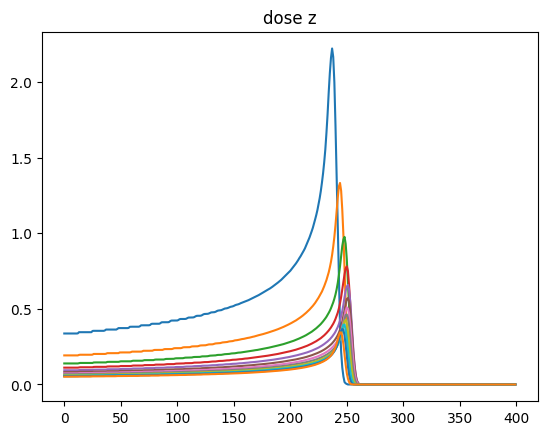

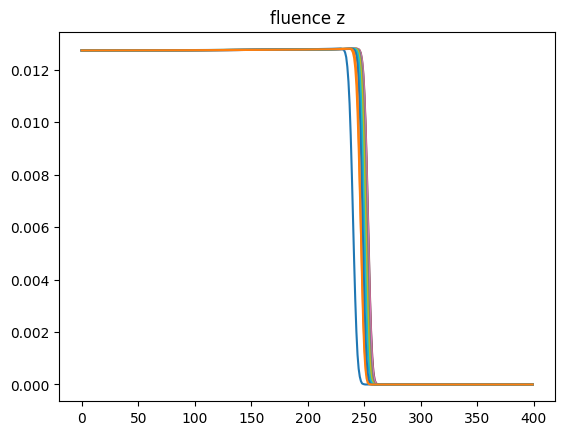

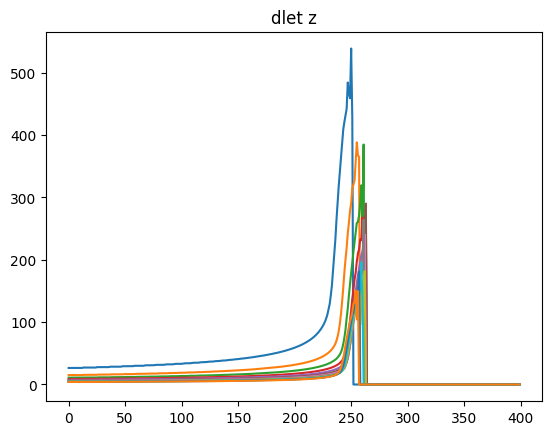

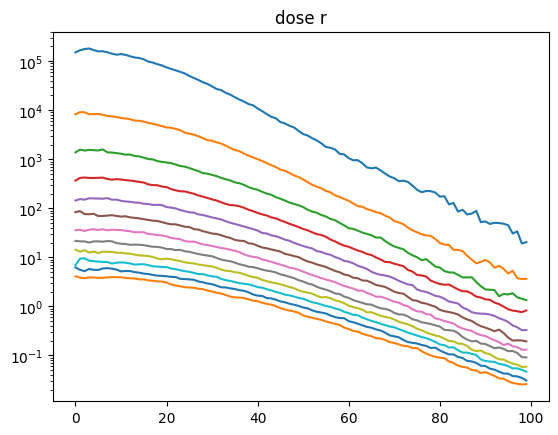

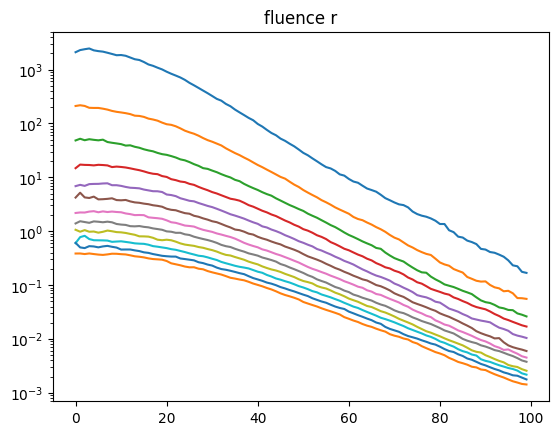

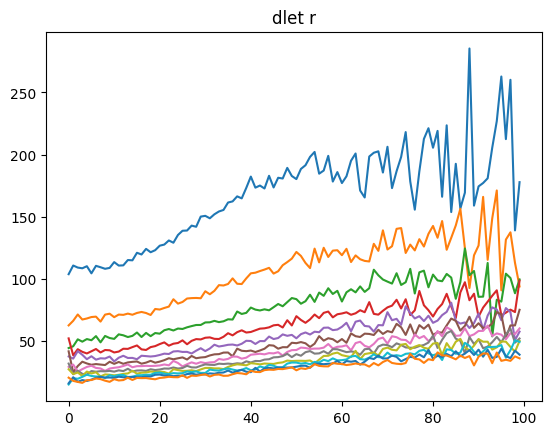

In [22]:
for i in data_z_dose[::2]:
    plt.title("dose z")
    plt.plot(i)
plt.show()
for i in data_z_fluence_protons[::2]:
    plt.title("fluence z")
    plt.plot(i)
plt.show()
for i in data_z_dlet_protons[::2]:
    plt.title("dlet z")
    plt.plot(i)
plt.show()
for i in data_r_dose[::2]:
    plt.title("dose r")
    plt.yscale("log")
    plt.plot(i)
plt.show()
for i in data_r_fluence_protons[::2]:
    plt.title("fluence r")
    plt.yscale("log")
    plt.plot(i)
plt.show()
for i in data_r_dlet_protons[::2]:
    plt.title("dlet r")
    plt.plot(i)
plt.show()



In [ ]:
n_lines = len(data_r_dose)//seeds_per_energy
cmap = mpl.colormaps['viridis']           # choose any colormap you like
colors = cmap(np.linspace(0, 1, n_lines))

plt.figure(figsize=(15,15))

for i in range(len(data_r_dose)):
    plt.plot(data_r_dose[i], color=colors[i//seeds_per_energy])
    # plt.ylim(1e0, 1e5)
plt.yscale("log")
plt.title("dose")
plt.show()

In [ ]:
n_lines = len(data_r_fluence_protons)//seeds_per_energy
cmap = mpl.colormaps['viridis']           # choose any colormap you like
colors = cmap(np.linspace(0, 1, n_lines))

plt.figure(figsize=(15,15))

for i in range(len(data_r_fluence_protons)):
    plt.plot(data_r_fluence_protons[i], color=colors[i//seeds_per_energy])
    # plt.ylim(0, 1e1)
plt.yscale("log")
plt.title("fluence")
plt.show()

In [ ]:
n_lines = len(data_r_dlet_protons)//seeds_per_energy
cmap = mpl.colormaps['viridis']           # choose any colormap you like
colors = cmap(np.linspace(0, 1, n_lines))

plt.figure(figsize=(15,15))

for i in range(len(data_r_dlet_protons)):
    plt.plot(data_r_dlet_protons[i], color=colors[i//seeds_per_energy])
    # plt.ylim(1e0, 1e5)
# plt.yscale("log")
plt.title("dlet")
plt.show()

## dlet preprocessing

In [ ]:
def find_peak(arr):
    before_peak = 10
    while arr[before_peak] <= 2.7*arr[before_peak-10]:
        before_peak += 1
    k = before_peak+1        
    while arr[k] > arr[k-1]:
        k+=1
    return k-1

def zero_tail(dist, threshold_frac=0.2, window=10):


    peak_idx = find_peak(dist)
    peak_val = dist[peak_idx]
    threshold = threshold_frac * peak_val
    
    post_peak = dist[peak_idx:]
    rolling = np.convolve(post_peak, np.ones(window)/window, mode='same')
    
    below = np.where(rolling < threshold)[0]
    if len(below) > 0:
        cutoff = peak_idx + below[0]
        result = dist.copy()
        result[cutoff:] = 0.0
        return result
    return dist

def zero_tail_with_fluence(arr_dlet, arr_fluence, threshold):
    for i in range(len(arr_dlet)):
        if arr_fluence[i] < threshold*np.max(arr_fluence):
            arr_dlet[i:] = 0
            return arr_dlet
    return arr_dlet

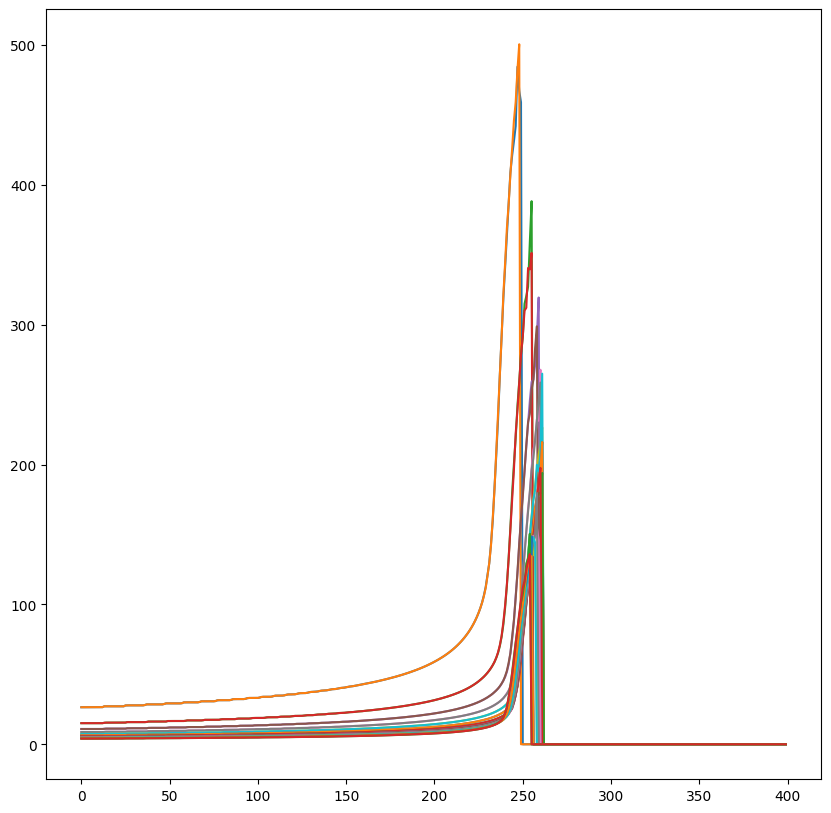

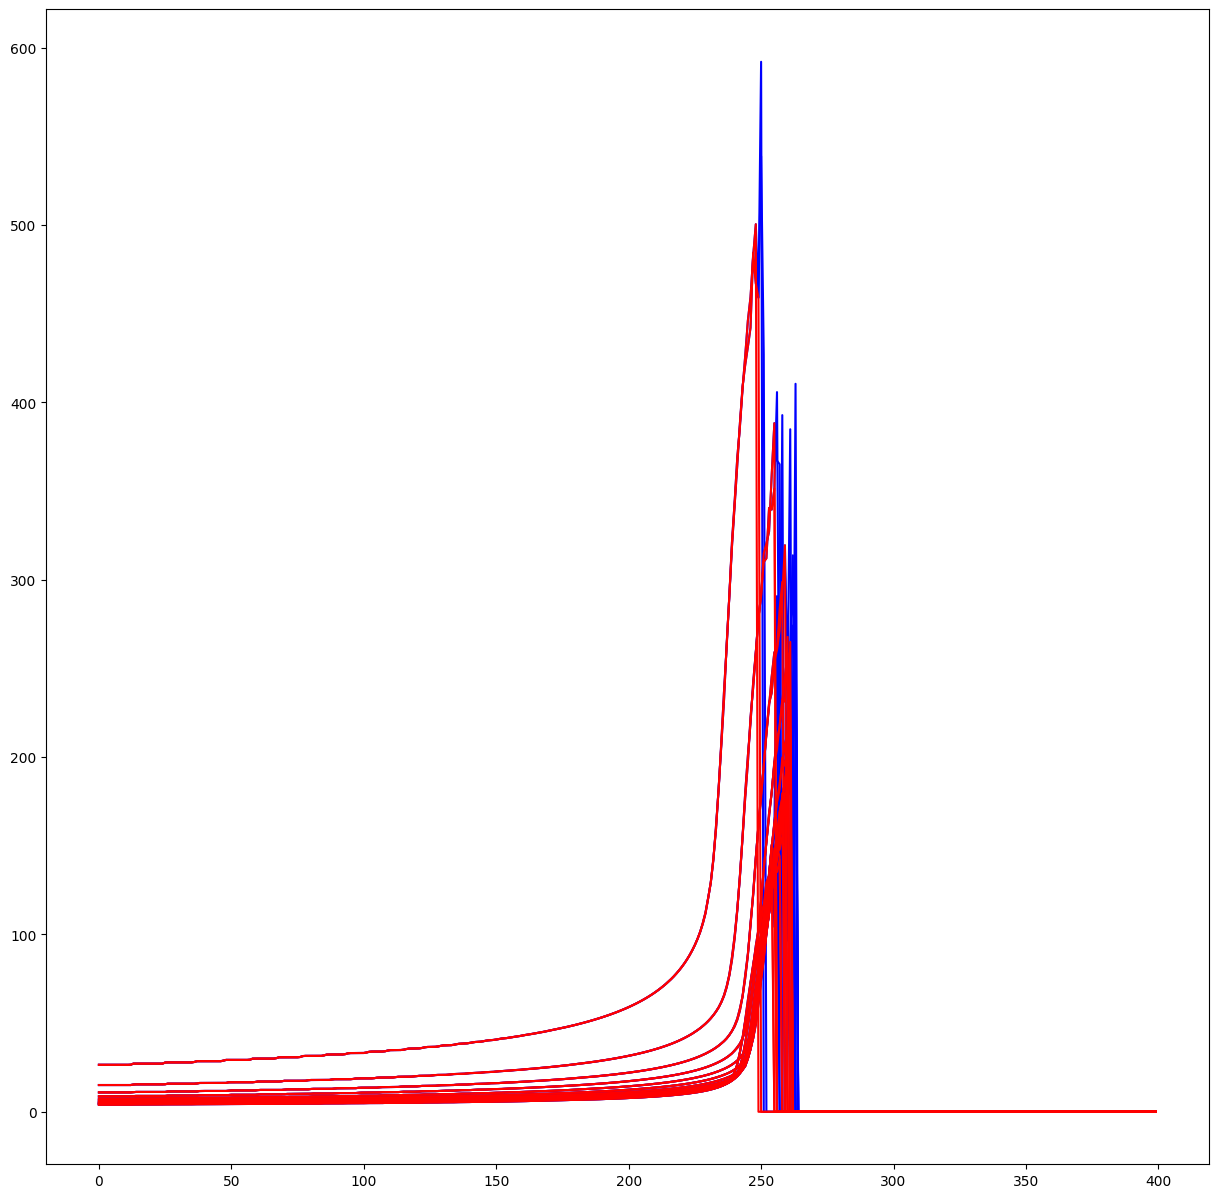

In [17]:
data_z_dlet_protons_processed = data_z_dlet_protons.copy()
process_arr  = list(zip(data_z_dlet_protons_processed, data_z_fluence_protons))

def zero_tail_pool(pair):
    dlet_arr = pair[0]
    fluence_arr =  pair[1]
    return zero_tail_with_fluence(dlet_arr,fluence_arr, 0.001)

with mp.Pool() as pool:
    results = pool.map(zero_tail_pool, process_arr, chunksize=1)

data_z_dlet_protons_processed[:] = results[:]

plt.figure(figsize=(10,10))
for i in data_z_dlet_protons_processed[::1]: 
    plt.plot(i)
plt.show()

plt.figure(figsize=(15,15))
for raw in data_z_dlet_protons:  # two separate loops for better visibility
    plt.plot(raw,color="blue")
for  processed in data_z_dlet_protons_processed: 
    plt.plot(processed, color = "red")
plt.show()

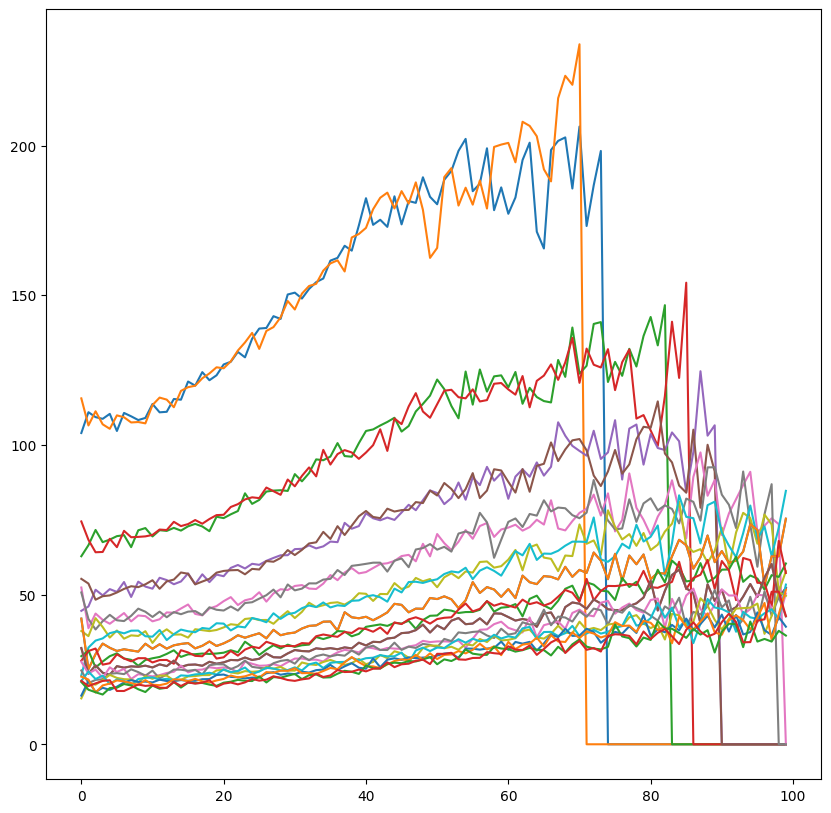

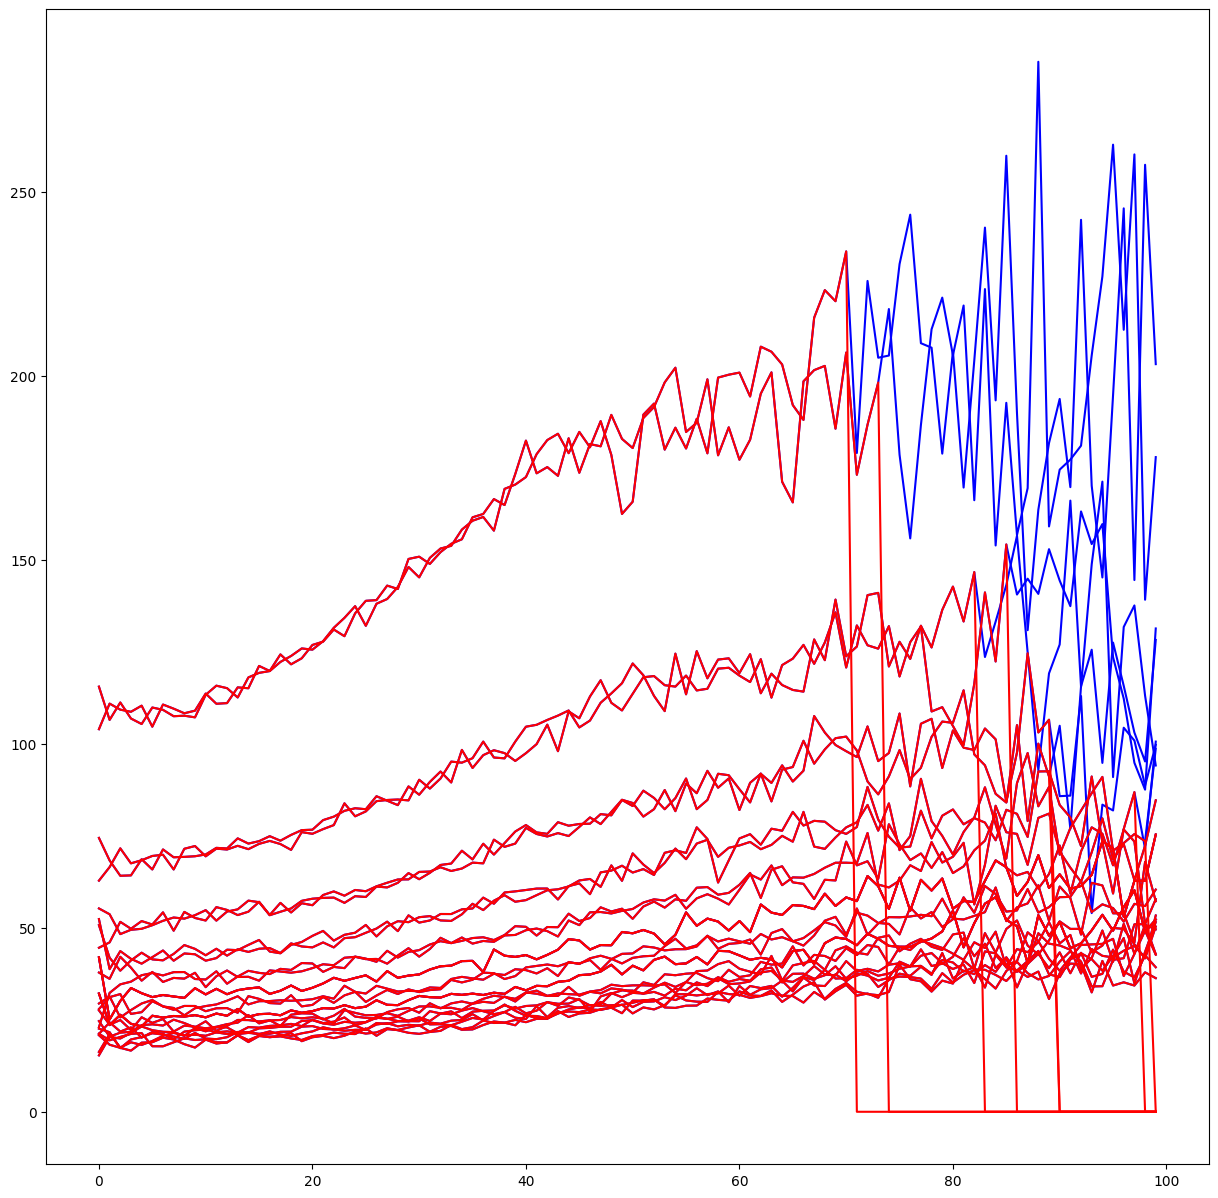

In [19]:
data_r_dlet_protons_processed = data_r_dlet_protons.copy()
process_arr  = list(zip(data_r_dlet_protons_processed, data_r_fluence_protons))

def zero_tail_pool(pair):
    dlet_arr = pair[0]
    fluence_arr =  pair[1]
    return zero_tail_with_fluence(dlet_arr,fluence_arr, 0.001)

with mp.Pool() as pool:
    results = pool.map(zero_tail_pool, process_arr, chunksize=1)

data_r_dlet_protons_processed[:] = results[:]


plt.figure(figsize=(10,10))
for i in data_r_dlet_protons_processed[::1]: 
    plt.plot(i)
plt.show()

plt.figure(figsize=(15,15))
for raw in data_r_dlet_protons:  # two separate loops for better visibility
    plt.plot(raw,color="blue")
for  processed in data_r_dlet_protons_processed: 
    plt.plot(processed, color = "red")
plt.show()

# log

In [ ]:
np.log10(data_r_dose)
np.log10(data_r_fluence_protons)

# Export train data

In [ ]:
TRAIN_DATAFILE = "training_data_g4batch4_raw_dlet.npz"
np.savez(TRAIN_DATAFILE, data_x=data_x, data_z_dose=data_z_dose, data_z_fluence_protons=data_z_fluence_protons, data_z_dlet_protons=data_z_dlet_protons_processed, data_r_dose=data_r_dose, data_r_fluence_protons=data_r_fluence_protons, data_r_dlet_protons = data_r_fluence_protons)


In [23]:


data_z_dlet_protons = data_z_dlet_protons_processed

print(f"Training on energies [{data_x[0],data_x[1]}...{data_x[-2],data_x[-1]}")
x_min, x_max = np.min(data_x), np.max(data_x)

# per-series maxima
max_z_dose = np.max(data_z_dose)
max_r_dose = np.max(data_r_dose)
# overall max (kept for compatibility)
max_dose = max(max_z_dose, max_r_dose)

max_z_fluence_protons = np.max(data_z_fluence_protons)
max_r_fluence_protons = np.max(data_r_fluence_protons)
max_fluence_protons = max(max_z_fluence_protons, max_r_fluence_protons)

max_z_dlet_protons = np.max(data_z_dlet_protons)
max_r_dlet_protons = np.max(data_r_dlet_protons)
max_dlet_protons = max(max_z_dlet_protons, max_r_dlet_protons)

normalized_x = (data_x - x_min) / (x_max-x_min)

# normalized per-series
normalized_data_z_dose = data_z_dose / max_z_dose
normalized_data_r_dose = data_r_dose / max_r_dose

normalized_data_z_fluence_protons = data_z_fluence_protons / max_z_fluence_protons
normalized_data_r_fluence_protons = data_r_fluence_protons / max_r_fluence_protons

normalized_data_z_dlet_protons = data_z_dlet_protons / max_z_dlet_protons
normalized_data_r_dlet_protons = data_r_dlet_protons / max_r_dlet_protons

class ProtonSurrogate(nn.Module):
    def __init__(self, hidden=256, depth=5):
        super().__init__()
        # shared trunk: scalar E → latent
        self.trunk = nn.Sequential(
            nn.Linear(1, hidden), nn.GELU(),
            *[layer for _ in range(depth - 1)
              for layer in (nn.Linear(hidden, hidden), nn.GELU())],
        )
        # depth heads (3 × 400 = 1200)
        self.head_z = nn.Linear(hidden, 3 * 400)
        # lateral heads (3 × 100 = 300)
        self.head_r = nn.Linear(hidden, 3 * 100)

    def forward(self, E):          # E: (B, 1), normalized
        h = self.trunk(E)
        z_out = self.head_z(h).view(-1, 3, 400)   # dose_z, fluence_z, dlet_z
        r_out = self.head_r(h).view(-1, 3, 100)   # dose_r, fluence_r, dlet_r
        return z_out, r_out

Training on energies [(20.0, 20.0)...(240.0, 240.0)


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [26]:
Y_z = torch.stack([
    torch.tensor(normalized_data_z_dose, dtype=torch.float32),
    torch.tensor(normalized_data_z_fluence_protons, dtype=torch.float32),
    torch.tensor(normalized_data_z_dlet_protons, dtype=torch.float32),
], dim=1).to(device)

Y_r =torch.stack([
    torch.tensor(normalized_data_r_dose, dtype=torch.float32),
    torch.tensor(normalized_data_r_fluence_protons, dtype=torch.float32),
    torch.tensor(normalized_data_r_dlet_protons, dtype=torch.float32),
], dim=1).to(device)

X_tensor = torch.tensor(normalized_x, dtype=torch.float32).to(device)
n_samples = n_samples = len(X_tensor)

In [32]:
model = ProtonSurrogate().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5000)
criterion = nn.MSELoss()
start_training = time.time()

total_epochs = 300
batch_size = 1
for epoch in range(total_epochs):
    train_loss = 0.0
    perm = torch.randperm(n_samples)
    for i in range(0, n_samples, batch_size):
        idx = perm[i:i+batch_size]
        x_batch, y_batch = X_tensor[idx], (Y_z[idx], Y_r[idx])

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred[0], y_batch[0]) + criterion(pred[1], y_batch[1])
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    num_batches = math.ceil(n_samples / batch_size)
    train_loss /= num_batches
    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:>4d} | ",
            f"Train loss: {train_loss:.4e} | ",
            f"LR: {current_lr:.2e}",
            f"Time: {time.time()-start_training:.2f}"
        )
        # with open(LOGS_PATH,"a+") as logs_file:
        #     logs_file.write(
        #         f"Epoch {epoch:>4d} | Train loss: {train_loss:.8e}  | LR: {current_lr:.2e} | Time: {time.time()-start_training:.2f}\n"
        #     )

Epoch    0 |  Train loss: 1.0776e-01 |  LR: 1.00e-03 Time: 0.67
Epoch   50 |  Train loss: 6.6889e-04 |  LR: 1.00e-03 Time: 7.78
Epoch  100 |  Train loss: 3.9282e-04 |  LR: 1.00e-03 Time: 15.28
Epoch  150 |  Train loss: 3.9504e-04 |  LR: 1.00e-03 Time: 22.60
Epoch  200 |  Train loss: 8.0513e-04 |  LR: 1.00e-03 Time: 29.84
Epoch  250 |  Train loss: 3.0783e-04 |  LR: 1.00e-03 Time: 37.33


In [35]:
model.eval()
X_norm_unique = np.unique(normalized_x).reshape(-1, 1)
with torch.no_grad():
    predictions = model(torch.from_numpy(X_norm_unique.astype(np.float32)).to(device))

In [39]:
predictions[0][0].shape

torch.Size([3, 400])

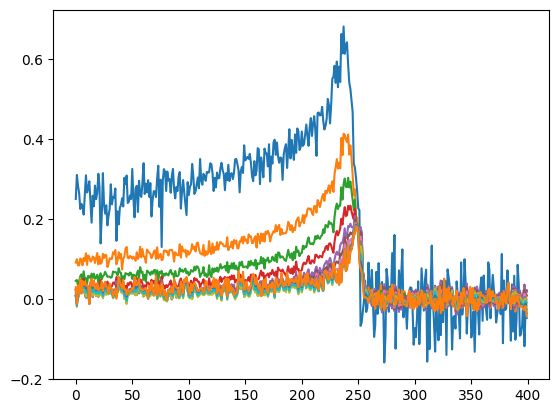

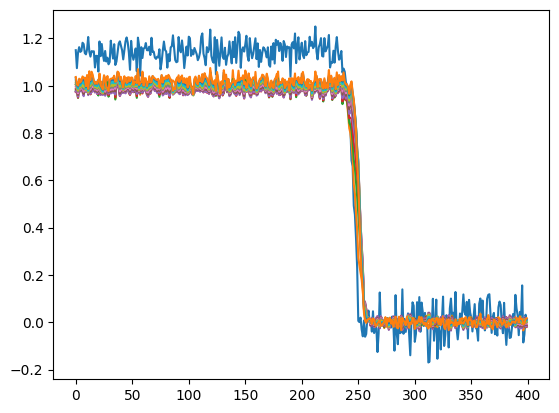

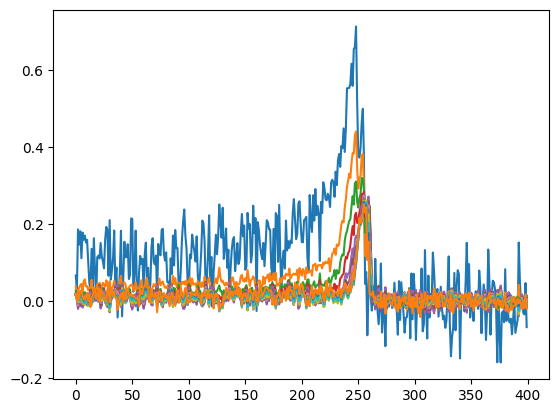

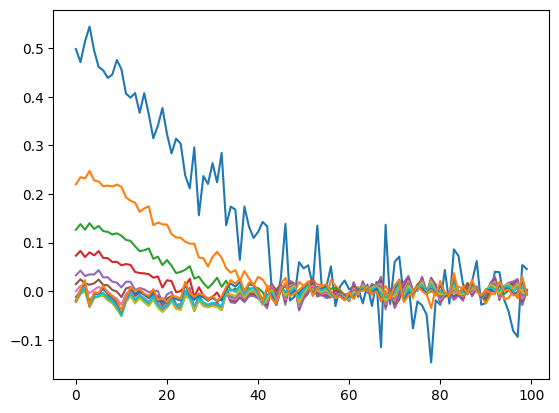

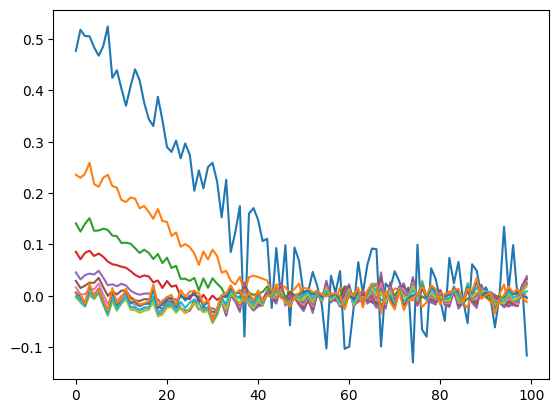

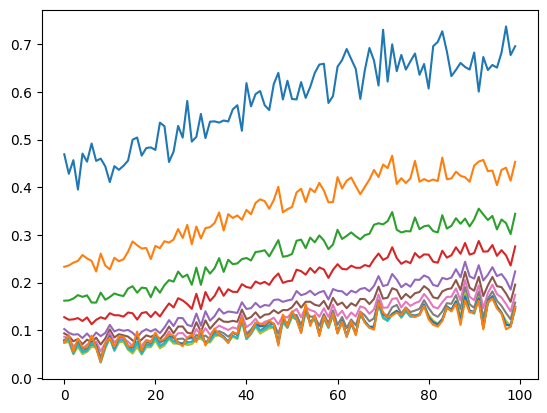

In [46]:
for i in range(len(predictions[0])):
    plt.plot(predictions[0][i][0].cpu())
plt.show()
for i in range(len(predictions[0])):
    plt.plot(predictions[0][i][1].cpu())
plt.show()
for i in range(len(predictions[0])):
    plt.plot(predictions[0][i][2].cpu())
plt.show()
for i in range(len(predictions[1])):
    plt.plot(predictions[1][i][0].cpu())
plt.show()
for i in range(len(predictions[1])):
    plt.plot(predictions[1][i][1].cpu())
plt.show()
for i in range(len(predictions[1])):
    plt.plot(predictions[1][i][2].cpu())
plt.show()